This is a slightly more advanced version of your earlier K-Means clustering example. You're now using **make_blobs() from scikit-learn** to generate synthetic data with three clusters.

In [1]:
import numpy as np  # Import NumPy for array and numerical operations
import pandas as pd  # Import pandas (useful for data handling, though not used here)
import matplotlib.pyplot as plt  # Import Matplotlib for creating plots
from matplotlib.colors import Normalize  # Used to control color scaling in the plot


In [2]:
# Import machine learning tools from scikit-learn
from sklearn.cluster import KMeans  # The K-Means clustering algorithm
from sklearn.datasets import make_blobs  # Utility to generate synthetic clustered data


In [3]:
# Define coordinates for the centers of synthetic data clusters
cent = [[1, 1], [2, 3], [3, 1]]


In [4]:
# Generate a dataset of 200 samples with 2 features (x and y)
# The data will form 3 clusters centered around 'cent'
# cluster_std=0.4 adds some spread (noise) around each cluster center
# random_state=1 ensures reproducibility
X, y = make_blobs(n_samples=200, n_features=2, centers=cent,
                  cluster_std=0.4, random_state=1)

#### Result:
- X → a (200 × 2) array of data points
- y → true cluster labels (not used in KMeans but useful for comparison)

In [10]:
# Initialize the K-Means model
# n_clusters=3 → we expect 3 groups
# n_init='auto' → automatically decide how many initializations to try for stable results
# random_state=5 → make results reproducible
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)

In [11]:
# Train (fit) the KMeans algorithm on our dataset X
kmeans.fit(X)

KMeans(n_clusters=3, random_state=42)

In [12]:
# Retrieve the coordinates of the computed cluster centers
centers = kmeans.cluster_centers_
print('Centroids:', centers, '\n')

#🧮 These are the mean positions of all points assigned to each cluster.

Centroids: [[1.04723086 0.9919885 ]
 [2.08585089 2.99789438]
 [2.98556144 1.04267906]] 



In [13]:
# Define a new test data point
test_point = np.array([[3,1]])

# Predict which cluster the test point belongs to (returns 0, 1, or 2)
print('Prediction:', kmeans.predict(test_point), '\n')


Prediction: [2] 



Text(0, 0.5, 'X2')

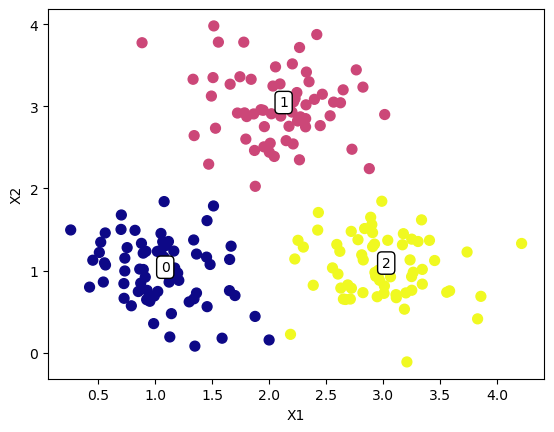

In [14]:
# Create a figure and axis for plotting
fig, ax = plt.subplots()

# Normalize color values so that clusters map nicely to colors
nm = Normalize(vmin=0, vmax=len(centers)-1)

# Scatter plot of the clustered data points
# Each point’s color represents its assigned cluster
ax.scatter(X[:, 0], X[:, 1],
           c=kmeans.predict(X), s=50, cmap='plasma', norm=nm)

# Plot the test point (star symbol)
# It is colored according to its predicted cluster
ax.scatter(test_point[:, 0], test_point[:, 1], marker='*',
           c=kmeans.predict(test_point), s=50, cmap='plasma', norm=nm)


# Plot each centroid and label it with its cluster number
for i in range(centers.shape[0]):
    ax.text(centers[i, 0], centers[i, 1], str(i), c='black',
            bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'))


# Add axis labels for clarity
ax.set_xlabel('X1')
ax.set_ylabel('X2')


### Conceptual Explanation of K-Means

K-Means is an unsupervised learning algorithm for finding natural groupings in data.
It works by:

- Picking k random centroids.
 - Assigning each point to the nearest centroid.
 - Updating centroids to be the mean of their assigned points.
 - Repeating until centroids stop moving.

### Result (What You’d See in the Plot)

 - Three distinct colored clusters of points.
 - Each cluster labeled with a number (0, 1, or 2) near its centroid.
 - A star marker representing the test point [3,1], colored according to its cluster.